In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import matplotlib.pyplot as plt
import src.data
import src.utils
from scipy.stats import multivariate_normal
import pandas as pd
import functools as ft
from collections import namedtuple
from IPython.display import Markdown, display
from omegaconf import OmegaConf
import yaml
import inspect
import hydra
from torchviz import make_dot
import os
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as colors
from matplotlib.colors import LogNorm 
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from PIL import Image
import kornia.filters as kfilts
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
#device = "cpu"

In [2]:
def plot_tensor(tensor, title = 'Logits Plot'):
    pos_tensor_numpy = tensor.numpy()
    plt.imshow(pos_tensor_numpy, cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.show()

def rmse_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    #mask = ~np.isnan(ds['input'])
    try:
        return rmse_based_scores(ds[ref_variable], ds[study_variable])[2:]
    except:
        return [np.nan, np.nan]

def psd_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    print(ds)
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]

def rmse_based_scores_lead(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def rmse_based_scores_day(da_rec, da_ref):
    # Calculate leaderboard RMSE
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return np.round(leaderboard_rmse.values, 5).item()

def rmse_based_scores(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        rmse_t,
        rmse_xy,
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )


def psd_based_scores(da_rec, da_ref):
    print('hello')
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    print(mean_psd_err)
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

def weighted_mse(err, weight = None):
    if weight is None:
        err_w = err
        non_zeros = (torch.ones_like(err) == 0.0)
    else:
        err_w = err * weight[None, ...]
        non_zeros = (torch.ones_like(err) * weight[None, ...]) == 0.0
    err_num = err.isfinite() & ~non_zeros
    if err_num.sum() == 0:
        return torch.scalar_tensor(1000.0, device=err_num.device).requires_grad_()
    loss = F.mse_loss(err_w[err_num], torch.zeros_like(err_w[err_num]))
    return loss

def pprint_cfg(cfg):
    display(Markdown("""```yaml\n\n""" +yaml.dump(OmegaConf.to_container(cfg), default_flow_style=None, indent=2)+"""\n\n```"""))


def update_dz_fig(frame, da, da_4dVN):
    plt.clf()  # Clear the previous frame
    global_min = np.min([da[frame, :, :], da_4dVN[frame, :, :]])
    global_max = np.max([da[frame, :, :], da_4dVN[frame, :, :]])
    
    mu_4dVN = rmse_based_scores_day(da[frame, :, :], da_4dVN[frame, :, :])

    corr_da_4dVN = xr.corr(da[frame, :, :], da_4dVN[frame, :, :])

    # Ground truth
    ax0 = fig.add_subplot(gs[0])
    im0 = ax0.imshow(da[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax0.text(0.5, 1.05, 'Ground truth', ha='center', va='bottom', transform=ax0.transAxes, fontsize=14)

    title_4dVarNet = '4dVarNet'
    subtitle_4dVarNet = f'Correlation: {corr_da_4dVN:.2f}\nRMSE Score: {mu_4dVN:.2f}'

    # 4dVarNet
    ax2 = fig.add_subplot(gs[1])
    im2 = ax2.imshow(da_4dVN[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax2.text(0.5, 1.1, title_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=14)
    ax2.text(0.5, 1.01, subtitle_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=10, linespacing=1.5)

    # Colorbar
    ax3 = fig.add_subplot(gs[2])
    plt.colorbar(im2, cax=ax3, label='ECS')

    ax3_position = ax3.get_position()
    new_position = [ax3_position.x0 - 0.03, ax3_position.y0, ax3_position.width, ax3_position.height]
    ax3.set_position(new_position)

In [3]:
tgt_ecs = xr.open_dataset('/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc')
#model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-06-19/19-17-51/sound_base_transfert/checkpoints/val_mse=2128.93279-epoch=252.ckpt'
#model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-10-10/09-37-52/sound_base_transfert/checkpoints/val_mse=3687.23485-epoch=471.ckpt'
#model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-10-10/09-43-53/sound_base_transfert/checkpoints/val_mse=3320.68040-epoch=405.ckpt'
#model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-03-20/17-58-39/sound_base_comfra/checkpoints/val_mse=692.42478-epoch=583.ckpt'
model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-10-23/15-49-11/sound_base_transfert/checkpoints/val_mse=2189.66427-epoch=312.ckpt'
#model_ckpt = '/Odyssey/private/ochapron/4dvarnet-starter/outputs/2024-10-21/08-52-09/sound_base_transfert/checkpoints/val_mse=959.59267-epoch=036.ckpt'
latitudes = tgt_ecs['lat']
longitudes = tgt_ecs['lon']
time_window = 1
inp_da = tgt_ecs.sel(time=slice(tgt_ecs.time[82], tgt_ecs.time[82] + pd.Timedelta(days= time_window - 1)))
times = inp_da['time']

crop_lat_start =  20
crop_lat_end = len(latitudes) -  20
crop_lon_start =  20
crop_lon_end = len(longitudes) -  20

In [4]:
model_ckpt_ssh = '/Odyssey/private/ochapron/ConcreteAE/pretrained_model.ckpt'
with hydra.initialize('config', version_base='1.3'):
    cfg_ssh = hydra.compose("main", overrides=['xp=base' ,'+params=bigger_model',])
print(cfg_ssh.model)
checkpoint_ssh = torch.load(model_ckpt_ssh)

if 'rec_weight' in checkpoint_ssh['state_dict']:
    del checkpoint_ssh['state_dict']['rec_weight']

lit_mod_ssh = hydra.utils.call(cfg_ssh.model)
lit_mod_ssh.load_state_dict(checkpoint_ssh['state_dict'])

/Odyssey/private/ochapron/miniconda/miniconda3/envs/4dvarnet-starter/lib/python3.9/site-packages/hydra/_internal/config_loader_impl.py:216: UserWarning: provider=hydra.searchpath in main, path=contrib is not available.
  warnings.warn(


{'_target_': 'src.models_v0.Lit4dVarNet', 'persist_rw': False, 'opt_fn': {'_target_': 'src.utils.cosanneal_lr_adam', '_partial_': True, 'lr': 0.001, 'T_max': '${trainer.max_epochs}'}, 'rec_weight': {'_target_': 'src.utils.get_triang_time_wei', 'patch_dims': '${datamodule.xrds_kw.patch_dims}', 'crop': {'time': 0, 'lat': 20, 'lon': 20}, 'offset': 1}, 'solver': {'_target_': 'src.models_v0.GradSolver', 'n_step': 15, 'lr_grad': 1000.0, 'prior_cost': {'_target_': 'src.models_v0.BilinAEPriorCost', 'dim_in': '${datamodule.xrds_kw.patch_dims.time}', 'dim_hidden': 64, 'bilin_quad': False, 'downsamp': 2}, 'obs_cost': {'_target_': 'src.models_v0.BaseObsCost'}, 'grad_mod': {'_target_': 'src.models_v0.ConvLstmGradModel', 'dim_in': '${datamodule.xrds_kw.patch_dims.time}', 'dim_hidden': 96}}, 'test_metrics': '${metrics.test_metrics}', 'pre_metric_fn': {'_target_': 'xarray.Dataset.sel', '_partial_': True, 'time': {'_target_': 'builtins.slice', '_args_': ['2012-10-22', '2012-12-02']}, 'lat': '${domain.t

<All keys matched successfully>

In [5]:
with hydra.initialize('config', version_base='1.3'):
    cfg = hydra.compose("main", overrides=['xp=sound_base_transfert' ,"+params= ['bigger_model']",])
    #cfg =  hydra.compose("main", overrides=['xp=sound_base_comfra' ,"+params= ['bigger_model']",])
print(cfg.model)
lit_mod = hydra.utils.call(cfg.model)
lit_mod.load_state_dict(torch.load(model_ckpt)['state_dict'])

print(lit_mod)

{'_target_': 'src.models.Lit4dVarNet', 'persist_rw': False, 'opt_fn': {'_target_': 'contrib.transfert.cosanneal_lr_adamw', '_partial_': True, 'lr': 0.001, 'T_max': '${trainer.max_epochs}', 'weight_decay': 0.001}, 'rec_weight': {'_target_': 'src.utils.get_triang_time_wei', 'patch_dims': '${datamodule.xrds_kw.patch_dims}', 'crop': {'time': 0, 'lat': 20, 'lon': 20}, 'offset': 1}, 'solver': {'_target_': 'src.models.GradSolver', 'n_step': 15, 'lr_grad': 1000.0, 'prior_cost': {'_target_': 'src.models.BilinAEPriorCost', 'dim_in': '${datamodule.xrds_kw.patch_dims.time}', 'dim_hidden': 64, 'bilin_quad': False, 'downsamp': 2}, 'obs_cost': {'_target_': 'src.models.BaseObsCost'}, 'grad_mod': {'_target_': 'src.models.ConvLstmGradModel', 'dim_in': '${datamodule.xrds_kw.patch_dims.time}', 'dim_hidden': 96}, 'weight_obs': 1.0, 'weight_prior': 1.0}, 'sampling_rate': 0.001, 'norm_type': 'z_score', 'test_metrics': '${metrics.test_metrics}', 'pre_metric_fn': {'_target_': 'xarray.Dataset.sel', '_partial_':

In [6]:
class GSModel(nn.Module):
    def __init__(self, time, lat, lon, rate, device):
        super(GSModel, self).__init__()
        self.logits = nn.Parameter(torch.zeros((2, time, lat, lon)))
        self.logits.data[1, :, :, :] = np.log(rate / (1 - rate))
        self.time_window, self.lat, self.lon  = time, lat, lon
        self.device = device

    def gumbel_softmax(self, logits, tau=1.0, hard=False):
        gumbels = -torch.empty_like(logits, memory_format=torch.legacy_contiguous_format).exponential_().log()  # ~Gumbel(0,1)
        gumbels = (logits + gumbels) / tau  # ~Gumbel(logits,tau)
        y_soft = gumbels.softmax(dim=0)
        if hard:
            index = y_soft.max(dim=0, keepdim=True)[1]
            y_hard = torch.zeros_like(logits, memory_format=torch.legacy_contiguous_format).scatter_(dim=0, index=index, value=1.0)
            ret = y_hard - y_soft.detach() + y_soft
        else:
            ret = y_soft
        return ret
    
    def compute_logits_loss(self, logits_init, batch, lit_mod, budget_obs = 0.01, tau=1.0, weight=1.0, hard=True):
        tgt_inp = batch.tgt.clone()
        logits = logits_init.to(self.device)
        
        # Generate mask using Gumbel-Softmax
        gs_output = F.gumbel_softmax(logits, tau=tau, hard=hard, dim=0)[0,:,:,:]
        mask_input = gs_output.view(self.time_window,self.lat, self.lon)
        mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
        normalized_selected_points = mask_input.mean()

        selected_tgt_inp = tgt_inp * mask_input
        selected_tgt_inp[mask_input == 0] = float('nan')
        selected_tgt_inp = selected_tgt_inp.detach() + (tgt_inp * mask_input) - (tgt_inp * mask_input).detach()
        batch = batch._replace(input=selected_tgt_inp)
        solver = lit_mod.solver
        
        with torch.enable_grad():
            output, _ = solver(batch)
        loss_mse = weighted_mse(output - batch.tgt, lit_mod.rec_weight)
        if normalized_selected_points >= budget_obs:
            weight = weight
        else:
            weight = 0
        loss = loss_mse + weight*normalized_selected_points
        return output, loss, mask_input, normalized_selected_points, loss_mse

    def forward(self, batch, lit_mod, budget_obs, tau, n_draw, weight):
        total_loss = 0
        total_points = 0
        total_mse = 0
        for _ in range(n_draw):
            output, loss_draw, mask, normalized_selected_points, loss_mse = self.compute_logits_loss(self.logits, batch, lit_mod, budget_obs=budget_obs, tau=tau, weight=weight, hard=True)
            total_loss += loss_draw
            total_points += normalized_selected_points
            total_mse += loss_mse
            del output, mask
            torch.cuda.empty_cache()
        mean_loss = total_loss / n_draw
        mean_points = total_points / n_draw
        mean_mse = total_mse / n_draw
        return mean_loss, mean_points, mean_mse

Iteration 0:
  Mean Loss: 0.014911783186687923
  Weight: 0
  Mean Normalized Selected Points: 0.020086806267499924
  Mean MSE Loss: 0.05956436258136151
Iteration 1:
  Mean Loss: 0.015184662237215334
  Weight: 0
  Mean Normalized Selected Points: 0.01996498927474022
  Mean MSE Loss: 0.06026083216577824
Iteration 2:
  Mean Loss: 0.014753065168051333
  Weight: 0
  Mean Normalized Selected Points: 0.01998090371489525
  Mean MSE Loss: 0.05941774873860108
Iteration 3:
  Mean Loss: 0.015417083178854136
  Weight: 0
  Mean Normalized Selected Points: 0.020059896633028984
  Mean MSE Loss: 0.06000339674400352
Iteration 4:
  Mean Loss: 0.015215072172008315
  Weight: 0
  Mean Normalized Selected Points: 0.019825231283903122
  Mean MSE Loss: 0.06030737814954014
Iteration 5:
  Mean Loss: 0.015173396965094857
  Weight: 0
  Mean Normalized Selected Points: 0.01985214091837406
  Mean MSE Loss: 0.06027763712973985
Iteration 6:
  Mean Loss: 0.015686349499994923
  Weight: 0
  Mean Normalized Selected Point

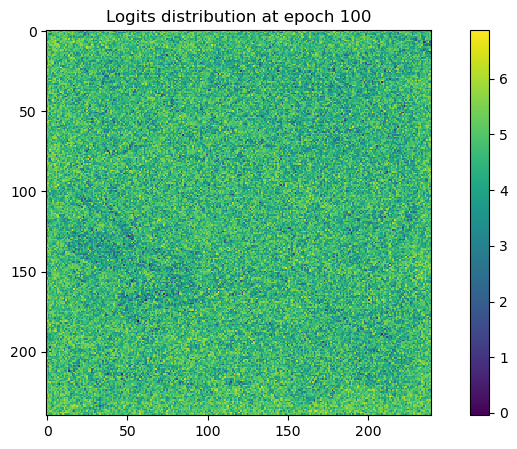

Iteration 100:
  Mean Loss: 0.011428466737876153
  Weight: 0.1
  Mean Normalized Selected Points: 0.024921586737036705
  Mean MSE Loss: 0.04273830586326468
Iteration 101:
  Mean Loss: 0.011845134083354225
  Weight: 0.2
  Mean Normalized Selected Points: 0.025019677355885506
  Mean MSE Loss: 0.04215199698468044
Iteration 102:
  Mean Loss: 0.012405292965879177
  Weight: 0.30000000000000004
  Mean Normalized Selected Points: 0.024967016652226448
  Mean MSE Loss: 0.04202520402311369
Iteration 103:
  Mean Loss: 0.013400137502875142
  Weight: 0.4
  Mean Normalized Selected Points: 0.024971067905426025
  Mean MSE Loss: 0.04296430887912571
Iteration 104:
  Mean Loss: 0.013518876534191895
  Weight: 0.5
  Mean Normalized Selected Points: 0.02511979267001152
  Mean MSE Loss: 0.041960248027471635
Iteration 105:
  Mean Loss: 0.014200970288118273
  Weight: 0.6000000000000001
  Mean Normalized Selected Points: 0.025280093774199486
  Mean MSE Loss: 0.04161484474942635
Iteration 106:
  Mean Loss: 0.014

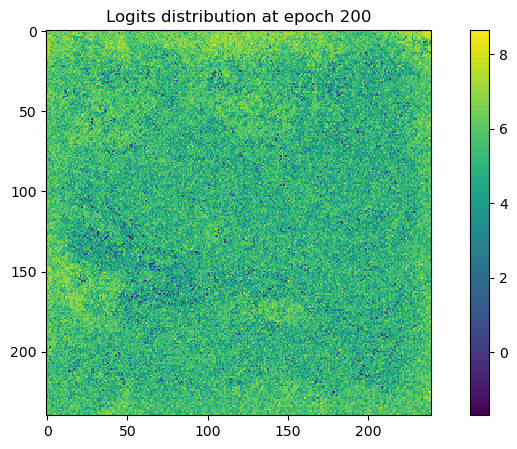

Iteration 200:
  Mean Loss: 0.07088846440724807
  Weight: 10.0
  Mean Normalized Selected Points: 0.02381828986108303
  Mean MSE Loss: 0.04588146050486582
Iteration 201:
  Mean Loss: 0.07113716806518537
  Weight: 10.0
  Mean Normalized Selected Points: 0.02395254746079445
  Mean MSE Loss: 0.0452920082838049
Iteration 202:
  Mean Loss: 0.0715905635593923
  Weight: 10.0
  Mean Normalized Selected Points: 0.02392621710896492
  Mean MSE Loss: 0.04556585206731481
Iteration 203:
  Mean Loss: 0.07148601735841523
  Weight: 10.0
  Mean Normalized Selected Points: 0.023943867534399033
  Mean MSE Loss: 0.045059972504493485
Iteration 204:
  Mean Loss: 0.07145650427546478
  Weight: 10.0
  Mean Normalized Selected Points: 0.024119215086102486
  Mean MSE Loss: 0.044961163758760934
Iteration 205:
  Mean Loss: 0.07159561304894466
  Weight: 10.0
  Mean Normalized Selected Points: 0.024280963465571404
  Mean MSE Loss: 0.04425422273193447
Iteration 206:
  Mean Loss: 0.0723196142897811
  Weight: 10.0
  Mea

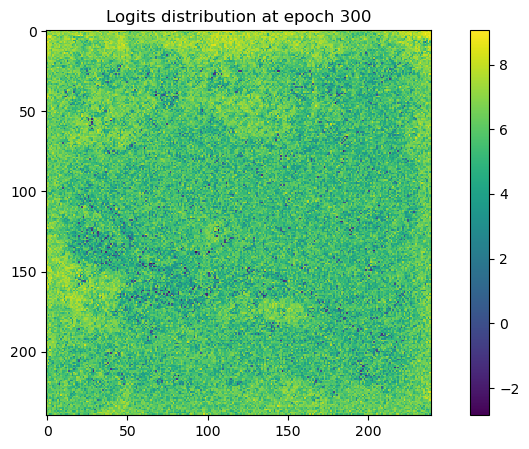

Iteration 300:
  Mean Loss: 0.06987406813765634
  Weight: 10.0
  Mean Normalized Selected Points: 0.02276620641350746
  Mean MSE Loss: 0.051872131326460603
Iteration 301:
  Mean Loss: 0.07026441330685322
  Weight: 10.0
  Mean Normalized Selected Points: 0.02292853221297264
  Mean MSE Loss: 0.050952862193040745
Iteration 302:
  Mean Loss: 0.07025343272521106
  Weight: 10.0
  Mean Normalized Selected Points: 0.0228949673473835
  Mean MSE Loss: 0.0517478451487858
Iteration 303:
  Mean Loss: 0.07008844155677267
  Weight: 10.0
  Mean Normalized Selected Points: 0.02288512885570526
  Mean MSE Loss: 0.05207134296884311
Iteration 304:
  Mean Loss: 0.06988196119789984
  Weight: 10.0
  Mean Normalized Selected Points: 0.022804688662290573
  Mean MSE Loss: 0.051997465803162446
Iteration 305:
  Mean Loss: 0.07014268413470749
  Weight: 10.0
  Mean Normalized Selected Points: 0.022826101630926132
  Mean MSE Loss: 0.052305345538239935
Iteration 306:
  Mean Loss: 0.06998777899766731
  Weight: 10.0
  M

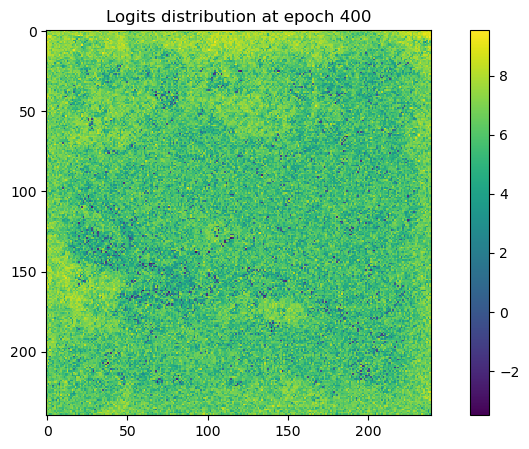

Iteration 400:
  Mean Loss: 0.07211547580547083
  Weight: 10.0
  Mean Normalized Selected Points: 0.024187790229916573
  Mean MSE Loss: 0.046606380753716904
Iteration 401:
  Mean Loss: 0.0718820817455302
  Weight: 10.0
  Mean Normalized Selected Points: 0.024059608578681946
  Mean MSE Loss: 0.04682851300374064
Iteration 402:
  Mean Loss: 0.07182963906603615
  Weight: 10.0
  Mean Normalized Selected Points: 0.024087386205792427
  Mean MSE Loss: 0.047461173967506355
Iteration 403:
  Mean Loss: 0.07171903927791345
  Weight: 10.0
  Mean Normalized Selected Points: 0.02407204918563366
  Mean MSE Loss: 0.047189169203099735
Iteration 404:
  Mean Loss: 0.07208380428862238
  Weight: 10.0
  Mean Normalized Selected Points: 0.024036172777414322
  Mean MSE Loss: 0.04731338504715209
Iteration 405:
  Mean Loss: 0.07208194017636516
  Weight: 10.0
  Mean Normalized Selected Points: 0.023999134078621864
  Mean MSE Loss: 0.047778760613872776
Iteration 406:
  Mean Loss: 0.0716348549521666
  Weight: 10.0


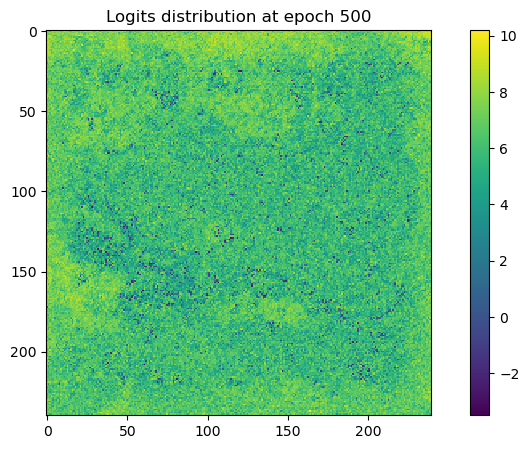

Iteration 500:
  Mean Loss: 0.07206498617075578
  Weight: 10.0
  Mean Normalized Selected Points: 0.02403385564684868
  Mean MSE Loss: 0.04797330127015435
Iteration 501:
  Mean Loss: 0.07206150445328575
  Weight: 10.0
  Mean Normalized Selected Points: 0.024015914648771286
  Mean MSE Loss: 0.04751723843456511
Iteration 502:
  Mean Loss: 0.0718664872551853
  Weight: 10.0
  Mean Normalized Selected Points: 0.024003762751817703
  Mean MSE Loss: 0.047719198530135475
Iteration 503:
  Mean Loss: 0.07195852291315988
  Weight: 10.0
  Mean Normalized Selected Points: 0.024030383676290512
  Mean MSE Loss: 0.04783588470184545
Iteration 504:
  Mean Loss: 0.07189767294937717
  Weight: 10.0
  Mean Normalized Selected Points: 0.024000002071261406
  Mean MSE Loss: 0.0473553533657949
Iteration 505:
  Mean Loss: 0.07189450482556359
  Weight: 10.0
  Mean Normalized Selected Points: 0.02414265088737011
  Mean MSE Loss: 0.04728156316844019
Iteration 506:
  Mean Loss: 0.07209272440453998
  Weight: 10.0
  Me

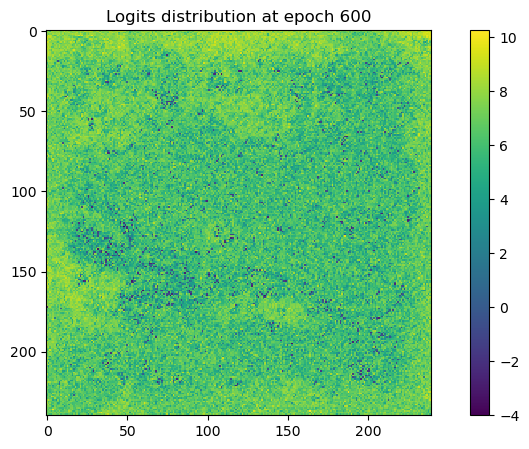

Iteration 600:
  Mean Loss: 0.072739697214755
  Weight: 10.0
  Mean Normalized Selected Points: 0.023943869397044182
  Mean MSE Loss: 0.05222034280257769
Iteration 601:
  Mean Loss: 0.07288735146012648
  Weight: 10.0
  Mean Normalized Selected Points: 0.023905960842967033
  Mean MSE Loss: 0.05224293456444892
Iteration 602:
  Mean Loss: 0.0729906733555518
  Weight: 10.0
  Mean Normalized Selected Points: 0.023930266499519348
  Mean MSE Loss: 0.05262986393343202
Iteration 603:
  Mean Loss: 0.07299315480301716
  Weight: 10.0
  Mean Normalized Selected Points: 0.024010417982935905
  Mean MSE Loss: 0.051704049834531564
Iteration 604:
  Mean Loss: 0.07264664925181075
  Weight: 10.0
  Mean Normalized Selected Points: 0.023939818143844604
  Mean MSE Loss: 0.05152645586234067
Iteration 605:
  Mean Loss: 0.07281730130845715
  Weight: 10.0
  Mean Normalized Selected Points: 0.02391608990728855
  Mean MSE Loss: 0.05181209015466711
Iteration 606:
  Mean Loss: 0.07270885050371144
  Weight: 10.0
  Me

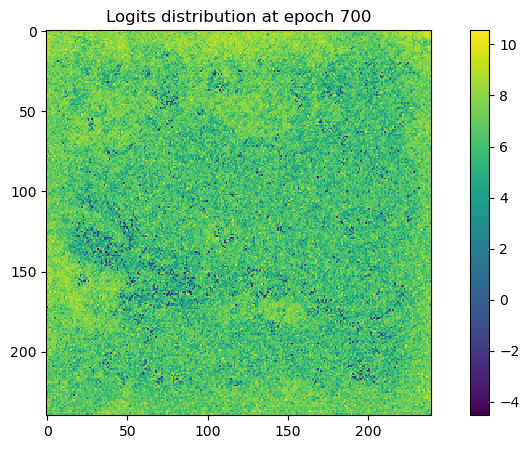

Iteration 700:
  Mean Loss: 0.07490945601756734
  Weight: 10.0
  Mean Normalized Selected Points: 0.024396702647209167
  Mean MSE Loss: 0.05455495948164894
Iteration 701:
  Mean Loss: 0.07413762955001718
  Weight: 10.0
  Mean Normalized Selected Points: 0.024394677951931953
  Mean MSE Loss: 0.054431470916404684
Iteration 702:
  Mean Loss: 0.07451732856854676
  Weight: 10.0
  Mean Normalized Selected Points: 0.02432754822075367
  Mean MSE Loss: 0.05490025091044335
Iteration 703:
  Mean Loss: 0.0746977739180017
  Weight: 10.0
  Mean Normalized Selected Points: 0.024271124973893166
  Mean MSE Loss: 0.0557566180768708
Iteration 704:
  Mean Loss: 0.0744606884713353
  Weight: 10.0
  Mean Normalized Selected Points: 0.024272862821817398
  Mean MSE Loss: 0.055894726159173916
Iteration 705:
  Mean Loss: 0.07478005130710659
  Weight: 10.0
  Mean Normalized Selected Points: 0.024487847462296486
  Mean MSE Loss: 0.054556272890898275
Iteration 706:
  Mean Loss: 0.07501379408413197
  Weight: 10.0
  

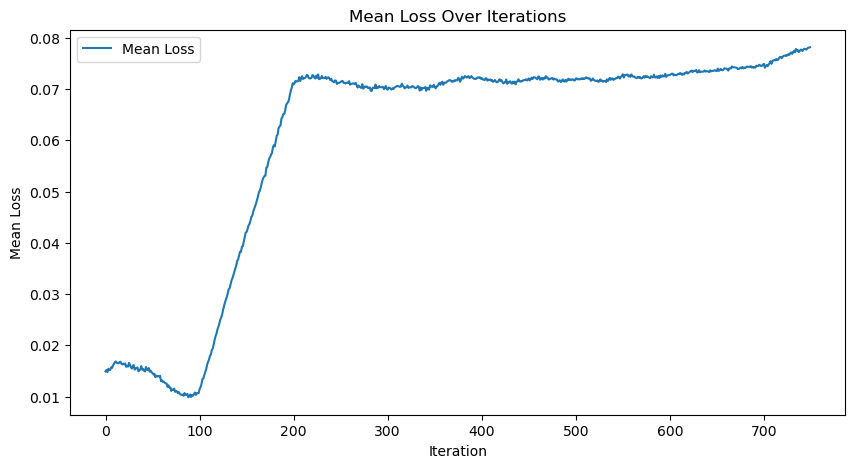

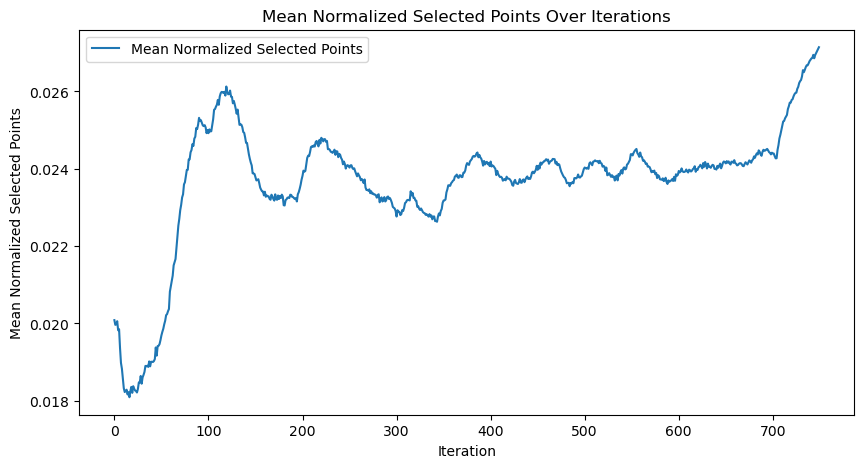

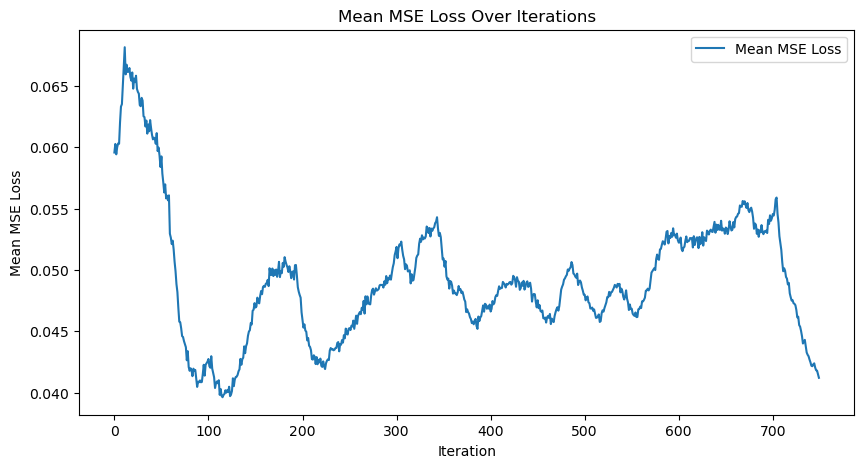

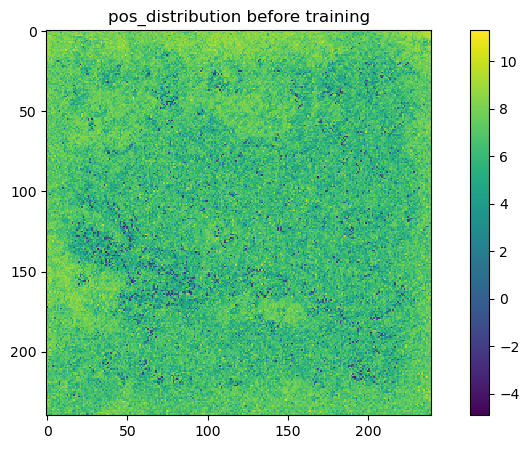

In [7]:
if len(inp_da.ecs.shape) < 3:
    time= 1
    lat, lon =  inp_da.shape
else:
    time, lat, lon = inp_da.ecs.shape

n_draw = 15
n_iter = 750
rate = 0.98
budget_obs = 1 - 0.98
accumulation_steps = 4

warmup_iterations =100
delta_weight = 0.1
max_weight = 10.0

# Initialize model
model = GSModel(time, lat, lon,  rate, device).to(device)

# Prepare data
mean_tgt = tgt_ecs.ecs.mean().item()
std_tgt = tgt_ecs.ecs.std().item()

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

tens_inp_da = torch.from_numpy(inp_da.ecs.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)

batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

lit_mod = lit_mod.to(device)
lit_mod = lit_mod.eval()

start_temp = 1.0
min_temp = 0.1
alpha = 0.9
lr = 1e-1

temperature = start_temp
mean_loss_list = []
mean_points_list = []
mean_mse_list = []

decay_rate = (min_temp / start_temp) ** (1 / (n_iter - 1))

# Initialize optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scaler = GradScaler()

# Define pooling layer
pooling_layer = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

# Training loop
for k in range(n_iter):
    optimizer.zero_grad()
    total_points = 0
    total_mse = 0
    #weight = (1/1)*(k/n_iter)
    # Adjust weight based on the current iteration
    if k < warmup_iterations:
        weight = 0
    else:
        # Calculate weight incrementally after warmup
        weight = min((k - warmup_iterations + 1) * delta_weight, max_weight)
    for i in range(accumulation_steps):
        with autocast():  # Mixed precision training
            mean_loss, normalized_selected_points, loss_mse = model(batch, lit_mod, budget_obs=budget_obs, tau=temperature, n_draw=n_draw, weight = weight)
            mean_loss = mean_loss / accumulation_steps  # Normalize loss by accumulation steps
            #mean_loss = mean_loss / accumulation_steps  # Normalize loss by accumulation steps
            total_points += normalized_selected_points / accumulation_steps  # Accumulate normalized points
            total_mse += loss_mse / accumulation_steps  # Accumulate MSE loss

        scaler.scale(mean_loss).backward()
        #pooled_logits = pooling_layer(model.logits)
        #upsampled_logits = F.interpolate(pooled_logits, size=model.logits.shape[2:], mode='bilinear', align_corners=False)
        #model.logits.data.copy_(upsampled_logits)
    #norm = model.logits.norm(p=2, dim=0, keepdim=True)
    #model.logits.data = np.log(rate / (1 - rate)) *(model.logits.data / norm)    
    #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.4)
    
    scaler.step(optimizer)
    scaler.update()
    #print(model.logits.grad)

    mean_loss_list.append(mean_loss.item())
    mean_points_list.append(total_points.item())
    mean_mse_list.append(total_mse.item())

    print(f"Iteration {k}:")
    print(f"  Mean Loss: {mean_loss.item()}")
    print(f"  Weight: {weight}")
    print(f"  Mean Normalized Selected Points: {total_points.item()}")
    print(f"  Mean MSE Loss: {total_mse.item()}")
    
    temperature = start_temp * (min_temp / start_temp) ** (1 / (n_iter - 1)) 
    #temperature = max(min_temp, temperature * decay_rate)
    if (k + 1) % 100 == 0:
        plt.figure(figsize=(10, 5))
        plt.title(f'Logits distribution at epoch {k + 1}')
        plt.imshow(model.logits[1, 0, :, :].detach().cpu().numpy(), cmap='viridis', interpolation='nearest')
        plt.colorbar()
        plt.show()
    #torch.cuda.empty_cache()

# Plot mean loss
plt.figure(figsize=(10, 5))
plt.plot(mean_loss_list, label='Mean Loss')
plt.xlabel('Iteration')
plt.ylabel('Mean Loss')
plt.title('Mean Loss Over Iterations')
plt.legend()
plt.show()

# Plot mean normalized selected points
plt.figure(figsize=(10, 5))
plt.plot(mean_points_list, label='Mean Normalized Selected Points')
plt.xlabel('Iteration')
plt.ylabel('Mean Normalized Selected Points')
plt.title('Mean Normalized Selected Points Over Iterations')
plt.legend()
plt.show()

# Plot mean MSE loss
plt.figure(figsize=(10, 5))
plt.plot(mean_mse_list, label='Mean MSE Loss')
plt.xlabel('Iteration')
plt.ylabel('Mean MSE Loss')
plt.title('Mean MSE Loss Over Iterations')
plt.legend()
plt.show()

# Visualization code (unchanged)
tensor_tgt = batch.tgt[0].detach().cpu().numpy()
xr_tgt = xr.DataArray(tensor_tgt, dims=inp_da.dims, coords=inp_da.coords)
da = xr_tgt.isel(lat=slice(crop_lat_start, crop_lat_end),
                 lon=slice(crop_lon_start, crop_lon_end))
da = da * std_tgt + mean_tgt

plt.figure(figsize=(10, 5))
plt.title('pos_distribution before training')
plt.imshow(model.logits[1, 0, :, :].detach().cpu().numpy(), cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

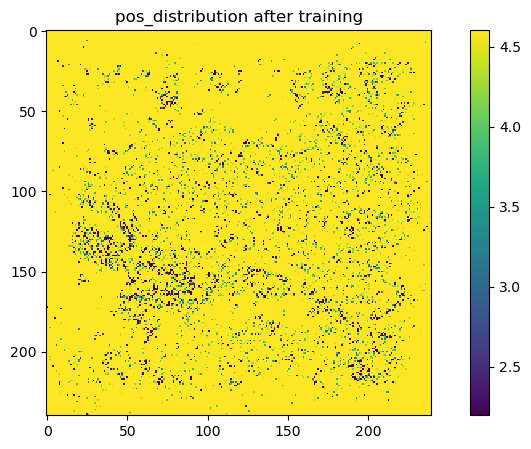

In [8]:
data = model.logits[1, 0, :, :].detach().cpu().numpy()
clipped_data = np.clip(data, np.log(0.9/0.1), np.log(0.999/0.01))

# Plot the clipped data
plt.figure(figsize=(10, 5))
plt.title('pos_distribution after training')
plt.imshow(clipped_data, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

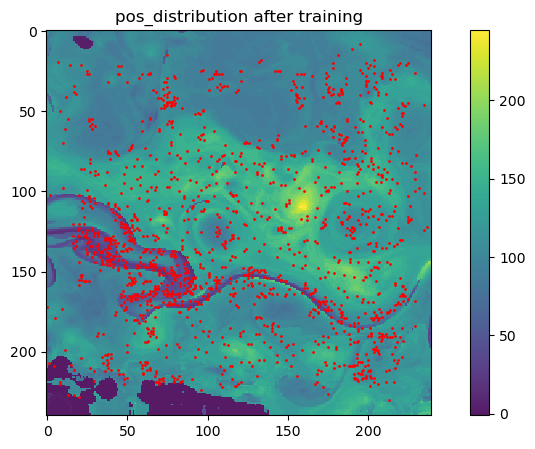

In [9]:
gs = F.gumbel_softmax(model.logits[:, 0, :, :], hard=True, dim=0)
datags = gs.detach().cpu().numpy()

# Extract the mask and background data
mask = datags[0]
background = inp_da.ecs[0]
# Identify the positions where the mask is one
y_positions, x_positions = np.where(mask == 1)

# Plot the background data
plt.figure(figsize=(10, 5))
plt.title('pos_distribution after training')
plt.imshow(background, cmap='viridis', interpolation='nearest', alpha=0.9)
plt.colorbar()

# Overlay the red dots on the positions where the mask is one
plt.scatter(x_positions, y_positions, color='red', s = 1)
plt.show()

RMSE: 0.2959722578525543
RMSE: 0.04031097855255421
Normalized Selected Points: 0.026927083730697632


/tmp/ipykernel_849659/2694766939.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse = weighted_mse(torch.tensor(error), lit_mod.rec_weight)


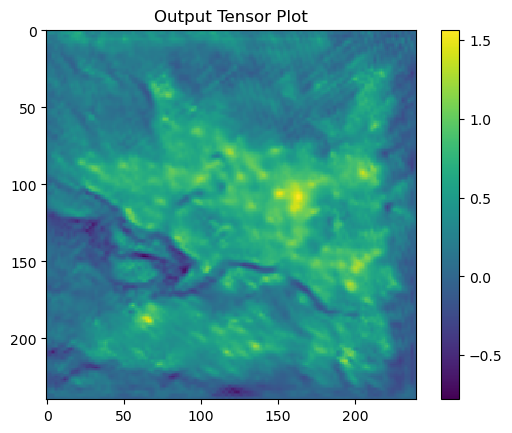

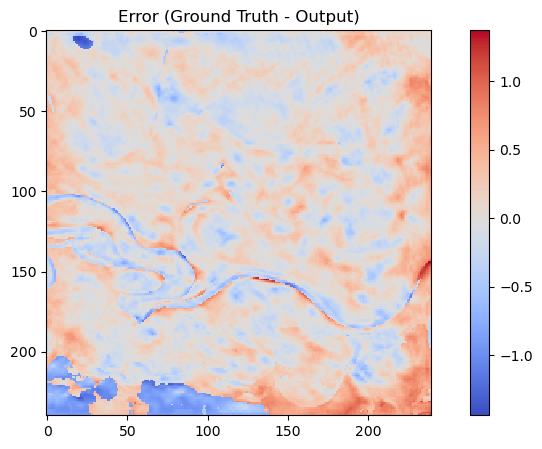

In [10]:
logits = model.logits
tau = 1
hard = True 
padding_size = 10 # Adjust this value as needed

time= 1
time,lat, lon = inp_da.ecs.shape
tgt_inp = tens_inp_da.clone()

# Prepare data
mean_tgt = tgt_ecs.ecs.mean().item()
std_tgt = tgt_ecs.ecs.std().item()

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

tens_inp_da = torch.from_numpy(inp_da.ecs.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)

batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

# Generate mask using Gumbel-Softmax
gs_output = F.gumbel_softmax(logits, tau=tau, hard=hard, dim=0)[0, :, :, :]
mask_input = gs_output.view(time,lat, lon)
mask_input = mask_input.unsqueeze(0) # Add batch dimension if necessary
normalized_selected_points = mask_input.mean()
# Create mask for observed data
mask = mask_input
# Apply mask to target input
selected_tgt_inp = tgt_inp * mask
selected_tgt_inp[mask == 0] = float('nan')
batch = batch._replace(input=selected_tgt_inp)
solver = lit_mod.solver
with torch.enable_grad():
    output, _ = solver(batch)
# Plot the output tensor
output_numpy = output.detach().cpu().numpy()
tens_inp_da_non = (tens_inp_da * std_tgt) + mean_tgt

error = (batch.tgt.detach().cpu().numpy()[0,0] - output_numpy)
rmse = np.sqrt(np.nanmean(error ** 2))
print(f"RMSE: {rmse}")

error = (batch.tgt- output)
output.unsqueeze(0)
output.unsqueeze(0)

rmse = weighted_mse(torch.tensor(error), lit_mod.rec_weight)
print(f"RMSE: {rmse}")
valid_points_mask = ~torch.isnan(selected_tgt_inp)
print(f"Normalized Selected Points: {normalized_selected_points}")

plt.imshow(output_numpy[0,0], cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Output Tensor Plot')
plt.show()

plt.figure(figsize=(10, 5))
plt.title('Error (Ground Truth - Output)')
plt.imshow(error.detach().cpu().numpy()[0,0], cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.show()

RMSE: 0.28191763162612915
RMSE: 0.05952960337673074
Normalized Selected Points: 0.019513890147209167


/tmp/ipykernel_849659/3312065884.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse = weighted_mse(torch.tensor(error), lit_mod.rec_weight)


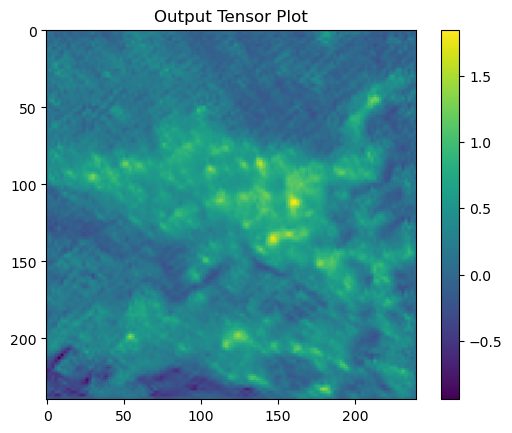

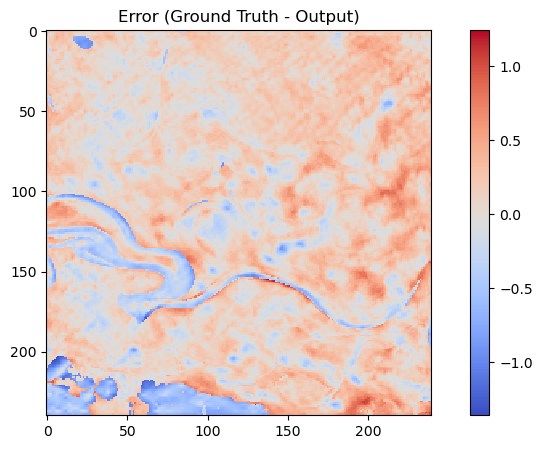

In [14]:
logits_inits_init = torch.zeros((2,1,240,240)).to(device)
logits_inits_init[1, :, :, :] = np.log(rate / (1 - rate))
tau = 1
hard = True 
padding_size = 10 # Adjust this value as needed

time= 1
time,lat, lon = inp_da.ecs.shape
tgt_inp = tens_inp_da.clone()

# Prepare data
mean_tgt = tgt_ecs.ecs.mean().item()
std_tgt = tgt_ecs.ecs.std().item()

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

tens_inp_da = torch.from_numpy(inp_da.ecs.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)

batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

# Generate mask using Gumbel-Softmax
gs_output = F.gumbel_softmax(logits_inits_init, tau=tau, hard=hard, dim=0)[0, :, :, :]
mask_input = gs_output.view(time,lat, lon)
mask_input = mask_input.unsqueeze(0) # Add batch dimension if necessary
normalized_selected_points = mask_input.mean()
# Create mask for observed data
mask = mask_input
# Apply mask to target input
selected_tgt_inp = tgt_inp * mask
selected_tgt_inp[mask == 0] = float('nan')
batch = batch._replace(input=selected_tgt_inp)
solver = lit_mod.solver
with torch.enable_grad():
    output, _ = solver(batch)
# Plot the output tensor
output_numpy = output.detach().cpu().numpy()
tens_inp_da_non = (tens_inp_da * std_tgt) + mean_tgt

error = (batch.tgt.detach().cpu().numpy()[0,0] - output_numpy)
rmse = np.sqrt(np.nanmean(error ** 2))
print(f"RMSE: {rmse}")

error = (batch.tgt- output)
output.unsqueeze(0)
output.unsqueeze(0)

rmse = weighted_mse(torch.tensor(error), lit_mod.rec_weight)
print(f"RMSE: {rmse}")
valid_points_mask = ~torch.isnan(selected_tgt_inp)
print(f"Normalized Selected Points: {normalized_selected_points}")

plt.imshow(output_numpy[0,0], cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Output Tensor Plot')
plt.show()

plt.figure(figsize=(10, 5))
plt.title('Error (Ground Truth - Output)')
plt.imshow(error.detach().cpu().numpy()[0,0], cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.show()

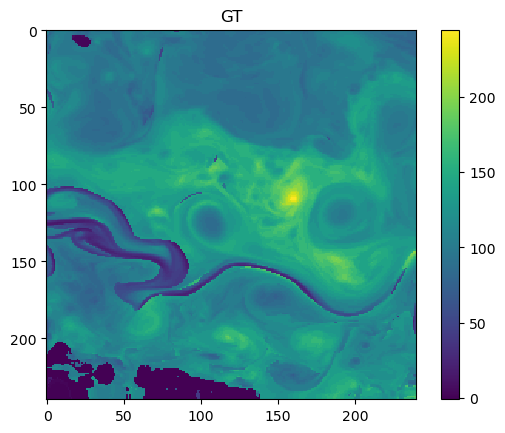

In [12]:
plt.imshow(inp_da.ecs[0], cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('GT')
plt.show()